In [44]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


In [45]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "breastmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info

{'python_class': 'BreastMNIST',
 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1',
 'MD5': '750601b1f35ba3300ea97c75c52ff8f6',
 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1',
 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364',
 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1',
 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1',
 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1',
 'MD5_224

In [46]:
transform_basic = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


(546, 78, 156)

In [47]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]

        # desnormalizar
        x = x * 0.5 + 0.5

        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

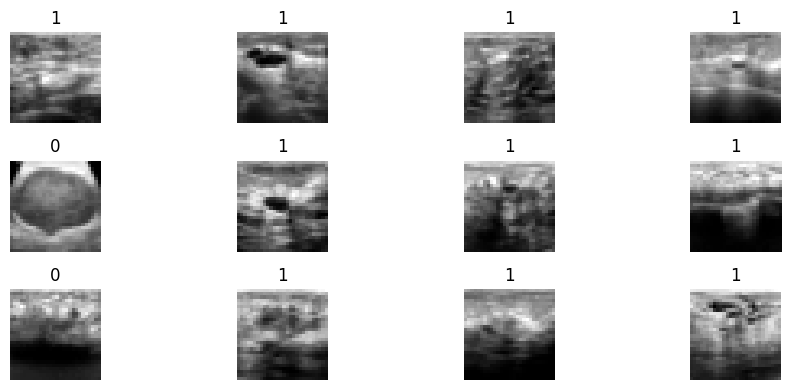

In [48]:
show_batch(train_dataset, n=12)

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [50]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

In [51]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [52]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):

    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)


    if len(np.unique(y_true)) < 2:
        auc = 0.5
    else:
        auc = roc_auc_score(y_true, y_prob)

    return acc, auc, y_true, y_pred, y_prob


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))

In [53]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 30

history_scratch = {
    "train_loss": [],
    "train_acc": [],
    "test_acc": [],
    "train_auc": [],
    "test_auc": []
}

for epoch in range(1, epochs + 1):


    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)


    train_acc, train_auc, _, _, _ = evaluate(model_scratch, train_loader)


    test_acc, test_auc, _, _, _ = evaluate(model_scratch, test_loader)


    history_scratch["train_loss"].append(train_loss)

    history_scratch["train_acc"].append(train_acc)
    history_scratch["test_acc"].append(test_acc)

    history_scratch["train_auc"].append(train_auc)
    history_scratch["test_auc"].append(test_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"loss={train_loss:.4f} | "
        f"train_acc={train_acc:.4f} | test_acc={test_acc:.4f} | "
        f"train_auc={train_auc:.4f} | test_auc={test_auc:.4f}"
    )

Epoch 01 | loss=0.6718 | train_acc=0.2692 | test_acc=0.2692 | train_auc=0.6095 | test_auc=0.5873
Epoch 02 | loss=0.5934 | train_acc=0.2692 | test_acc=0.2692 | train_auc=0.6443 | test_auc=0.6243
Epoch 03 | loss=0.5137 | train_acc=0.2692 | test_acc=0.2692 | train_auc=0.6450 | test_auc=0.6259
Epoch 04 | loss=0.4812 | train_acc=0.2692 | test_acc=0.2692 | train_auc=0.6846 | test_auc=0.6612
Epoch 05 | loss=0.4529 | train_acc=0.2692 | test_acc=0.2692 | train_auc=0.7177 | test_auc=0.6888
Epoch 06 | loss=0.4493 | train_acc=0.2857 | test_acc=0.3077 | train_auc=0.7186 | test_auc=0.6884
Epoch 07 | loss=0.4684 | train_acc=0.2839 | test_acc=0.2949 | train_auc=0.7858 | test_auc=0.7558
Epoch 08 | loss=0.4263 | train_acc=0.4451 | test_acc=0.4679 | train_auc=0.8005 | test_auc=0.7548
Epoch 09 | loss=0.4274 | train_acc=0.4689 | test_acc=0.4872 | train_auc=0.8615 | test_auc=0.8306
Epoch 10 | loss=0.4124 | train_acc=0.6429 | test_acc=0.6474 | train_auc=0.8759 | test_auc=0.8465
Epoch 11 | loss=0.4067 | train

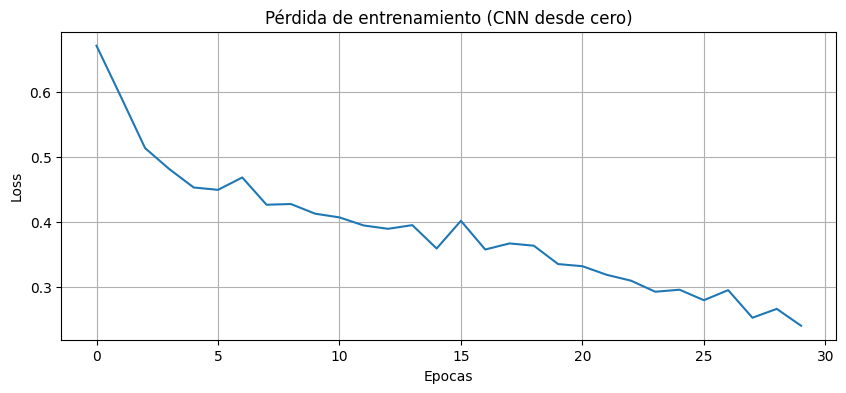

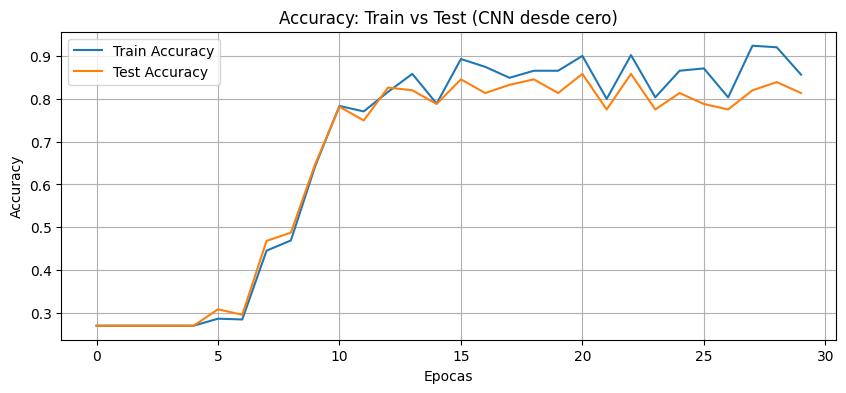

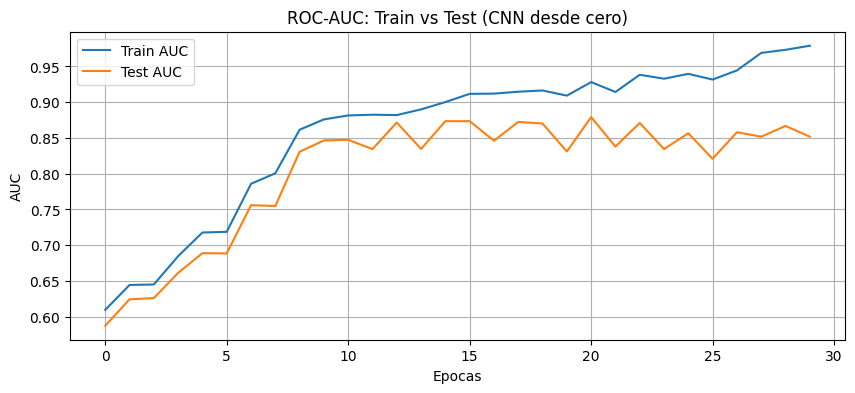

In [54]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Epocas")
plt.ylabel("Loss")
plt.grid()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_acc"], label="Train Accuracy")
plt.plot(history_scratch["test_acc"], label="Test Accuracy")
plt.title("Accuracy: Train vs Test (CNN desde cero)")
plt.xlabel("Epocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_auc"], label="Train AUC")
plt.plot(history_scratch["test_auc"], label="Test AUC")
plt.title("ROC-AUC: Train vs Test (CNN desde cero)")
plt.xlabel("Epocas")
plt.ylabel("AUC")
plt.legend()
plt.grid()
plt.show()

In [55]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8141
Test ROC-AUC:  0.8517

              precision    recall  f1-score   support

           0     0.9333    0.3333    0.4912        42
           1     0.8014    0.9912    0.8863       114

    accuracy                         0.8141       156
   macro avg     0.8674    0.6623    0.6888       156
weighted avg     0.8369    0.8141    0.7799       156



array([[ 14,  28],
       [  1, 113]])

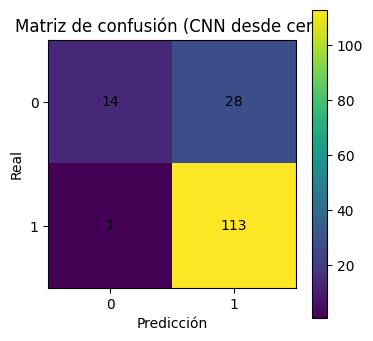

In [56]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


In [57]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

train_dataset_aug = DataClass(
    split="train",
    transform=transform_aug,
    download=True
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [58]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6

history_aug = {
    "train_loss": [],
    "train_acc": [],
    "test_acc": [],
    "train_auc": [],
    "test_auc": []
}

for epoch in range(1, epochs + 1):


    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)


    train_acc, train_auc, _, _, _ = evaluate(model_aug, train_loader_aug)


    test_acc, test_auc, _, _, _ = evaluate(model_aug, test_loader)


    history_aug["train_loss"].append(train_loss)

    history_aug["train_acc"].append(train_acc)
    history_aug["test_acc"].append(test_acc)

    history_aug["train_auc"].append(train_auc)
    history_aug["test_auc"].append(test_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"loss={train_loss:.4f} | "
        f"train_acc={train_acc:.4f} | test_acc={test_acc:.4f} | "
        f"train_auc={train_auc:.4f} | test_auc={test_auc:.4f}"
    )

Epoch 01 | loss=0.6552 | train_acc=0.7253 | test_acc=0.7244 | train_auc=0.6496 | test_auc=0.6385
Epoch 02 | loss=0.5887 | train_acc=0.7436 | test_acc=0.7436 | train_auc=0.7019 | test_auc=0.7120
Epoch 03 | loss=0.5682 | train_acc=0.6264 | test_acc=0.6859 | train_auc=0.6973 | test_auc=0.7043
Epoch 04 | loss=0.5172 | train_acc=0.6355 | test_acc=0.6731 | train_auc=0.7307 | test_auc=0.7210
Epoch 05 | loss=0.4950 | train_acc=0.6465 | test_acc=0.6474 | train_auc=0.7487 | test_auc=0.7304
Epoch 06 | loss=0.4915 | train_acc=0.6465 | test_acc=0.6410 | train_auc=0.7555 | test_auc=0.7567


In [59]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)

print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")

Sin augmentation  | test_acc=0.6410 | test_auc=0.7567
Con augmentation  | test_acc=0.6410 | test_auc=0.7567


In [60]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1)),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1)),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape

torch.Size([64, 3, 224, 224])

In [61]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)

resnet = resnet.to(device)


for param in resnet.parameters():
    param.requires_grad = False


for param in resnet.fc.parameters():
    param.requires_grad = True

resnet

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [62]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4

history_tl_stage1 = {
    "train_loss": [],
    "train_acc": [],
    "test_acc": [],
    "train_auc": [],
    "test_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)


    train_acc, train_auc, _, _, _ = evaluate(resnet, train_loader_tl)


    test_acc, test_auc, _, _, _ = evaluate(resnet, test_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)

    history_tl_stage1["train_acc"].append(train_acc)
    history_tl_stage1["test_acc"].append(test_acc)

    history_tl_stage1["train_auc"].append(train_auc)
    history_tl_stage1["test_auc"].append(test_auc)

    print(
        f"Stage1 Epoch {epoch:02d} | "
        f"loss={train_loss:.4f} | "
        f"train_acc={train_acc:.4f} | test_acc={test_acc:.4f} | "
        f"train_auc={train_auc:.4f} | test_auc={test_auc:.4f}"
    )

Stage1 Epoch 01 | loss=0.5867 | train_acc=0.7363 | test_acc=0.7372 | train_auc=0.6006 | test_auc=0.6855
Stage1 Epoch 02 | loss=0.5463 | train_acc=0.7308 | test_acc=0.7372 | train_auc=0.6506 | test_auc=0.6637
Stage1 Epoch 03 | loss=0.5314 | train_acc=0.7308 | test_acc=0.6859 | train_auc=0.6561 | test_auc=0.7051
Stage1 Epoch 04 | loss=0.5140 | train_acc=0.7454 | test_acc=0.7885 | train_auc=0.7114 | test_auc=0.7548


In [63]:
for param in resnet.layer4.parameters():
    param.requires_grad = True

for param in resnet.fc.parameters():
    param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]

len(trainable_params)

17

In [64]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4

history_tl_stage2 = {
    "train_loss": [],
    "train_acc": [],
    "test_acc": [],
    "train_auc": [],
    "test_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)


    train_acc, train_auc, _, _, _ = evaluate(resnet, train_loader_tl)


    test_acc, test_auc, _, _, _ = evaluate(resnet, test_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)

    history_tl_stage2["train_acc"].append(train_acc)
    history_tl_stage2["test_acc"].append(test_acc)

    history_tl_stage2["train_auc"].append(train_auc)
    history_tl_stage2["test_auc"].append(test_auc)

    print(
        f"Stage2 Epoch {epoch:02d} | "
        f"loss={train_loss:.4f} | "
        f"train_acc={train_acc:.4f} | test_acc={test_acc:.4f} | "
        f"train_auc={train_auc:.4f} | test_auc={test_auc:.4f}"
    )

Stage2 Epoch 01 | loss=0.4790 | train_acc=0.8278 | test_acc=0.8141 | train_auc=0.8496 | test_auc=0.8515
Stage2 Epoch 02 | loss=0.3401 | train_acc=0.8828 | test_acc=0.8590 | train_auc=0.9081 | test_auc=0.8695
Stage2 Epoch 03 | loss=0.2811 | train_acc=0.9066 | test_acc=0.8654 | train_auc=0.9529 | test_auc=0.8937
Stage2 Epoch 04 | loss=0.2240 | train_acc=0.9414 | test_acc=0.8782 | train_auc=0.9741 | test_auc=0.9039


In [65]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.8782 | test_auc=0.9039

              precision    recall  f1-score   support

           0     0.8485    0.6667    0.7467        42
           1     0.8862    0.9561    0.9198       114

    accuracy                         0.8782       156
   macro avg     0.8673    0.8114    0.8332       156
weighted avg     0.8760    0.8782    0.8732       156



array([[ 28,  14],
       [  5, 109]])

In [66]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.8782 | auc=0.9039
CNN desde cero (con aug)  | acc=0.6410 | auc=0.7567
Transfer learning (ResNet) | acc=0.8782 | auc=0.9039


In [67]:
def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))

    if target_class is None:
        target_class = torch.argmax(logits, dim=1).item()

    score = logits[0, target_class]

    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


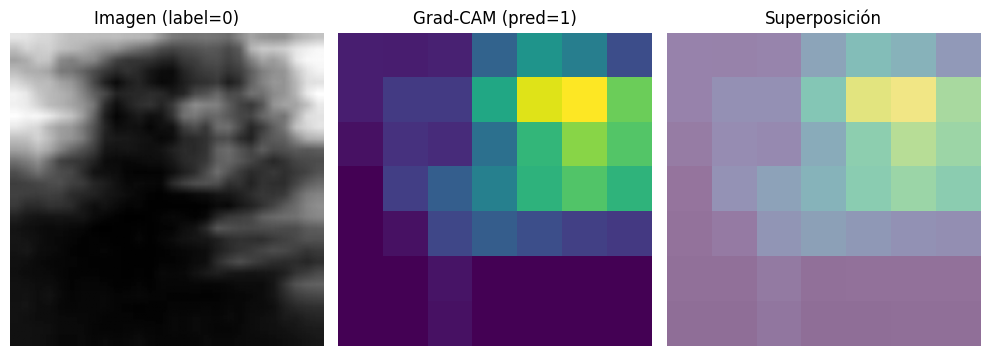

In [68]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


In [69]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

El modelo muestra un desempeño sólido en clasificación binaria de imágenes médicas.

La buena capacidad discriminativa (AUC aproximadamente 0.85 en test). Sin embargo, presenta un ligero sobreajuste y una tendencia a priorizar sensibilidad sobre especificidad, generando un número elevado de falsos positivos.

La visualización mediante Grad-CAM confirma que el modelo aprende regiones relevantes de la imagen, aunque con resolución espacial limitada. El uso de transfer learning con ResNet mejora significativamente el rendimiento respecto a la CNN desde cero, lo que valida la efectividad de arquitecturas preentrenadas en este tipo de datasets médicos de tamaño reducido.